<a href="https://colab.research.google.com/github/Laxmi0412/Retail-sales-intelligence-system/blob/main/notebooks/retail_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [23]:
df.head()
df.info()
df.isnull().sum()
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [25]:
df.drop_duplicates(inplace=True)

# Handle missing values safely
df = df.dropna(subset=["Sales", "Profit"])

df["Discount"] = df["Discount"].fillna(0)

In [26]:
# Profit Margin
df["Profit_Margin"] = (df["Profit"] / df["Sales"]) * 100

# Loss flag
df["Loss_Making"] = df["Profit"] < 0

# Effective Sales after discount
df["Effective_Sales"] = df["Sales"] * (1 - df["Discount"])

In [27]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
profit_margin = (total_profit / total_sales) * 100

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Overall Profit Margin:", round(profit_margin, 2), "%")

Total Sales: 2297200.8603000003
Total Profit: 286397.0217
Overall Profit Margin: 12.47 %


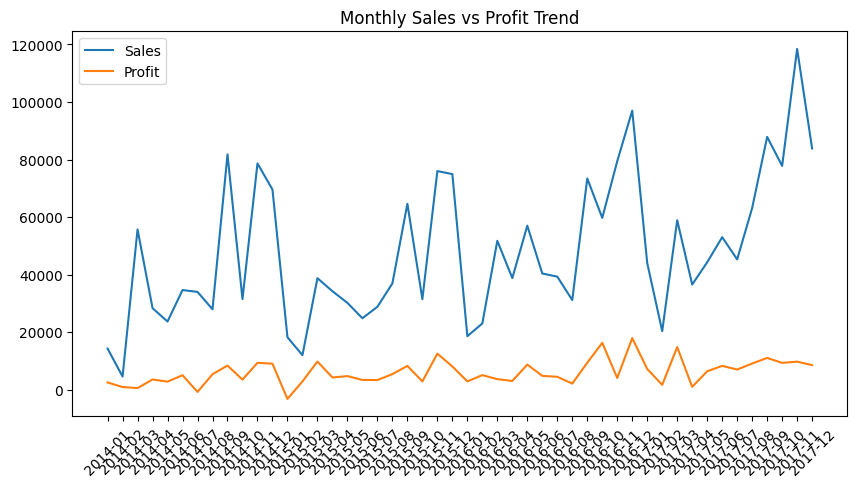

In [28]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Month"] = df["Order Date"].dt.to_period("M")

monthly = df.groupby("Month")[["Sales", "Profit"]].sum().reset_index()

plt.figure(figsize=(10,5))
plt.plot(monthly["Month"].astype(str), monthly["Sales"], label="Sales")
plt.plot(monthly["Month"].astype(str), monthly["Profit"], label="Profit")

plt.xticks(rotation=45)
plt.title("Monthly Sales vs Profit Trend")
plt.legend()
plt.show()

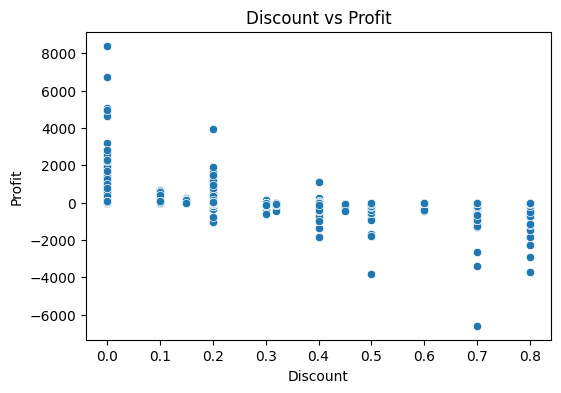

,Discount,Profit
Discount,1.000000,-0.219487
Profit,-0.219487,1.000000


In [29]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["Discount"], y=df["Profit"])
plt.title("Discount vs Profit")
plt.show()

df[["Discount", "Profit"]].corr()

In [30]:
region = df.groupby("Region")[["Sales", "Profit"]].sum().reset_index()
region.sort_values(by="Profit", ascending=False)

,Region,Sales,Profit
3,West,725457.8245,108418.4489
1,East,678781.2400,91522.7800
2,South,391721.9050,46749.4303
0,Central,501239.8908,39706.3625


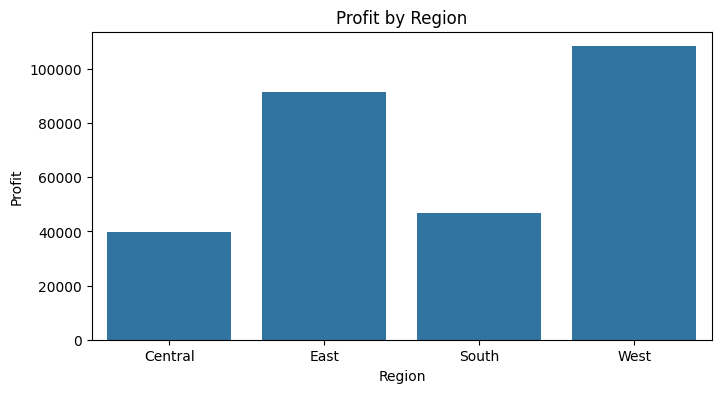

In [31]:
plt.figure(figsize=(8,4))
sns.barplot(x="Region", y="Profit", data=region)
plt.title("Profit by Region")
plt.show()

In [32]:
category = df.groupby("Category")[["Sales", "Profit"]].sum().reset_index()
category.sort_values(by="Profit", ascending=False)

,Category,Sales,Profit
2,Technology,836154.0330,145454.9481
1,Office Supplies,719047.0320,122490.8008
0,Furniture,741999.7953,18451.2728


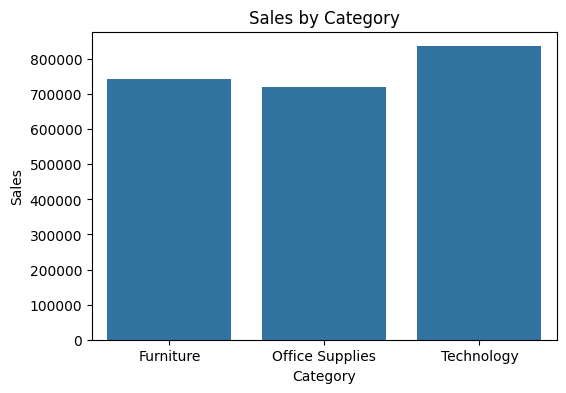

In [33]:
plt.figure(figsize=(6,4))
sns.barplot(x="Category", y="Sales", data=category)
plt.title("Sales by Category")
plt.show()

In [34]:
loss_products = df[df["Profit"] < 0]

loss_summary = loss_products.groupby("Sub-Category")["Profit"].sum().sort_values()

loss_summary

,Profit
Sub-Category,
Binders,-38510.4964
Tables,-32412.1483
Machines,-30118.6682
Bookcases,-12152.2060
Chairs,-9880.8413
Appliances,-8629.6412
Phones,-7530.6235
Furnishings,-6490.9134
Storage,-6426.3038


In [35]:
df.to_csv("cleaned_superstore_data.csv", index=False)

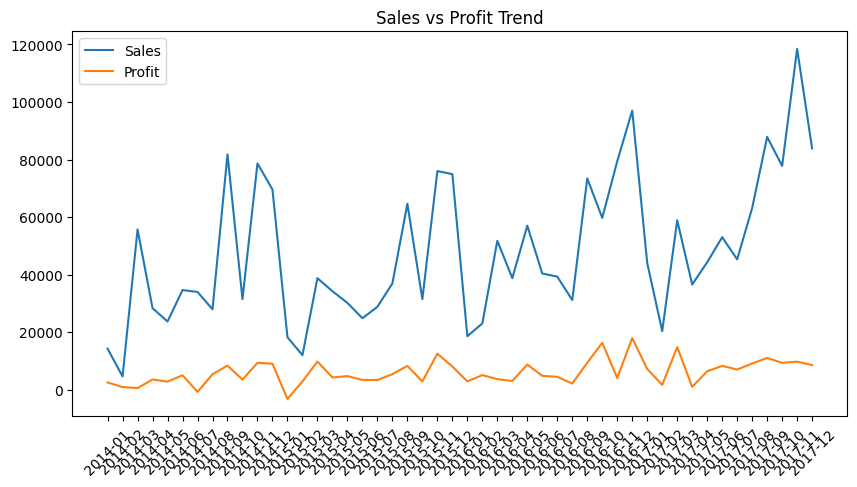

In [36]:
import matplotlib.pyplot as plt

df["Month"] = df["Order Date"].dt.to_period("M")

monthly = df.groupby("Month")[["Sales", "Profit"]].sum().reset_index()

plt.figure(figsize=(10,5))
plt.plot(monthly["Month"].astype(str), monthly["Sales"], label="Sales")
plt.plot(monthly["Month"].astype(str), monthly["Profit"], label="Profit")

plt.xticks(rotation=45)
plt.title("Sales vs Profit Trend")
plt.legend()
plt.show()

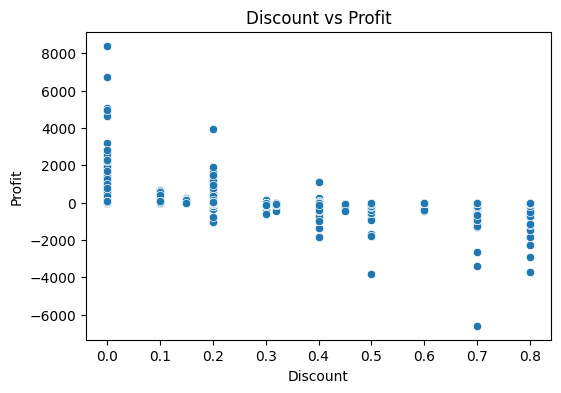

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="Discount", y="Profit")

plt.title("Discount vs Profit")
plt.show()

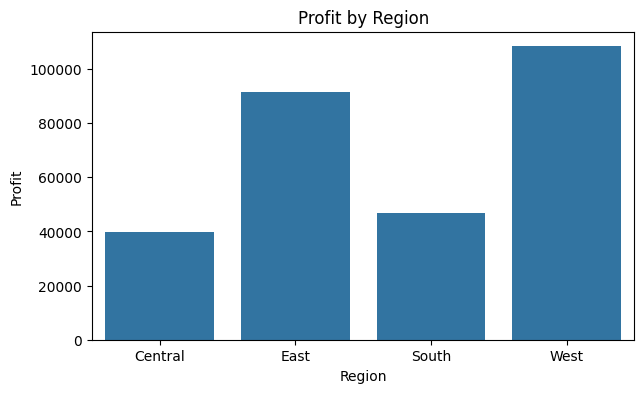

In [38]:
region = df.groupby("Region")["Profit"].sum().reset_index()

plt.figure(figsize=(7,4))
sns.barplot(data=region, x="Region", y="Profit")

plt.title("Profit by Region")
plt.show()

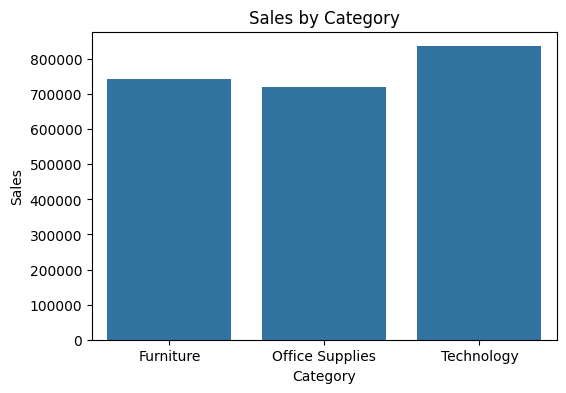

In [39]:
category = df.groupby("Category")[["Sales", "Profit"]].sum().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=category, x="Category", y="Sales")

plt.title("Sales by Category")
plt.show()

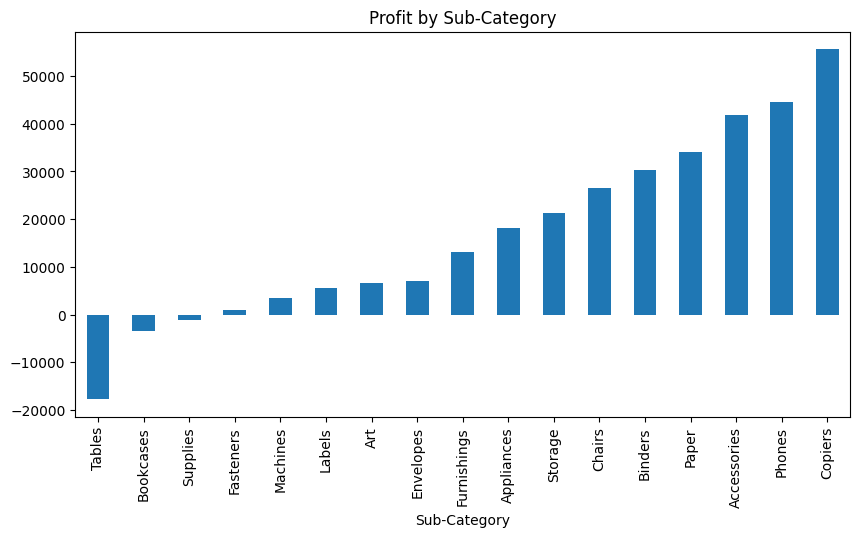

In [40]:
subcat = df.groupby("Sub-Category")["Profit"].sum().sort_values()

plt.figure(figsize=(10,5))
subcat.plot(kind="bar")

plt.title("Profit by Sub-Category")
plt.show()

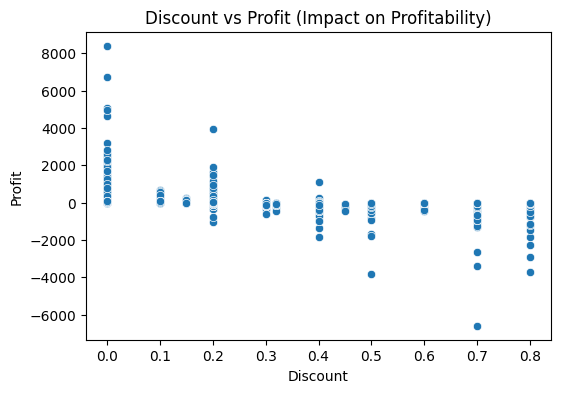

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="Discount", y="Profit")

plt.title("Discount vs Profit (Impact on Profitability)")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

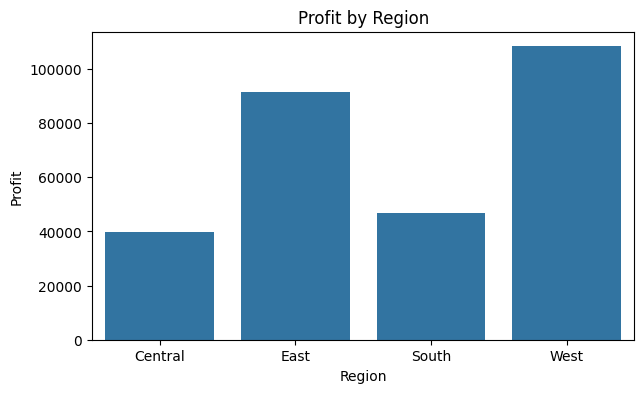

In [42]:
region_profit = df.groupby("Region")["Profit"].sum().reset_index()

plt.figure(figsize=(7,4))
sns.barplot(data=region_profit, x="Region", y="Profit")

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.show()

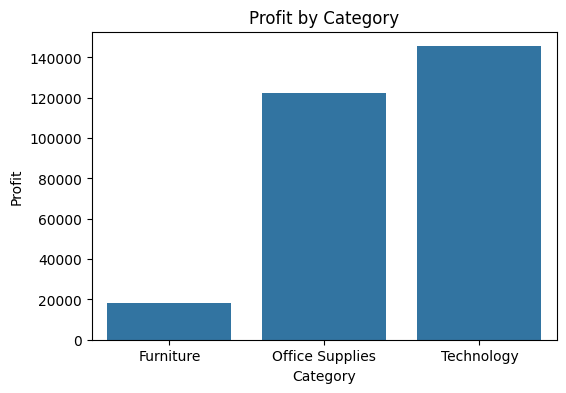

In [43]:
category_profit = df.groupby("Category")["Profit"].sum().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=category_profit, x="Category", y="Profit")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

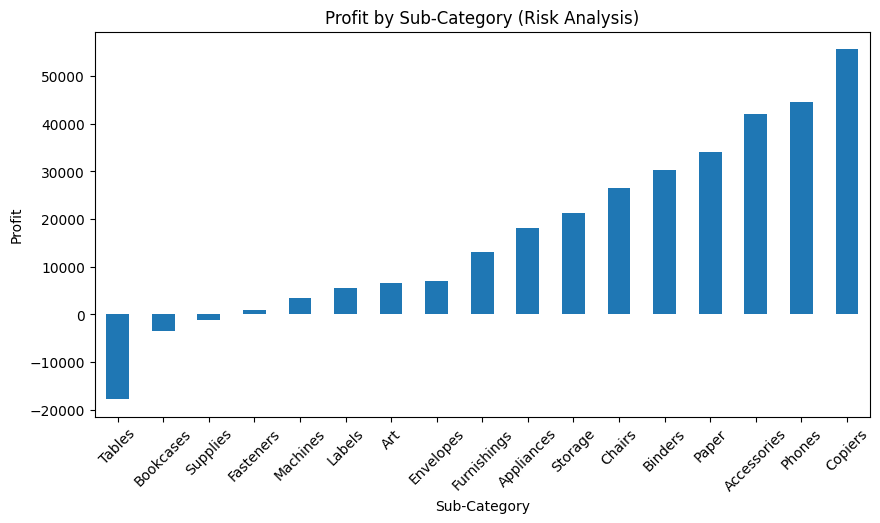

In [44]:
subcat_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values()

plt.figure(figsize=(10,5))
subcat_profit.plot(kind="bar")

plt.title("Profit by Sub-Category (Risk Analysis)")
plt.xlabel("Sub-Category")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()